# Automotive Warranty and Service KPI Analysis 

#### Objective
This project analyzes vehicle warranty claims and service visits data to identify: -
- major warranty cost drivers
- most frequent issue categories
- claim approval and rejection patterns
- model-level warranty burden
- service cost patterns
- regional claim concentration

The analysis is based on three datasets:
- vehicles
- service_visits
- warranty_claims

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
db_path = "warranty_kpi.db"
conn = sqlite3.connect(db_path)

In [4]:
# creating cleaned views to ensure that warranty KPIs reflect only valid warranty activity
setup_sql = """
DROP VIEW IF EXISTS valid_warranty_claims;
CREATE VIEW valid_warranty_claims AS
SELECT wc.*
FROM warranty_claims wc
JOIN vehicles v
  ON wc.vehicle_id = v.vehicle_id
WHERE wc.claim_date <= v.warranty_end_date;

DROP VIEW IF EXISTS valid_service_visits;
CREATE VIEW valid_service_visits AS
SELECT sv.*
FROM service_visits sv
JOIN vehicles v
  ON sv.vehicle_id = v.vehicle_id
WHERE sv.service_date <= v.warranty_end_date;
"""
conn.executescript(setup_sql)
print("Cleaned views created successfully.")

Cleaned views created successfully.


In [6]:
vehicles_count = pd.read_sql_query("select count(*) as vehicles from vehicles;", conn)
service_count = pd.read_sql_query("select count(*) as service_visits from service_visits;", conn)
claims_count = pd.read_sql_query("select count(*) as warranty_claims from warranty_claims;", conn)

print("Vehicles:", vehicles_count.iloc[0, 0])
print("Service visits:", service_count.iloc[0, 0])
print("Warranty claims:", claims_count.iloc[0, 0])

Vehicles: 1000
Service visits: 3000
Warranty claims: 1200


In [10]:
#data quality check
dq_claims = pd.read_sql_query("""
SELECT COUNT(*) AS claims_outside_warranty
FROM warranty_claims wc
JOIN vehicles v
  ON wc.vehicle_id = v.vehicle_id
WHERE wc.claim_date > v.warranty_end_date;
""", conn)

dq_services = pd.read_sql_query("""
SELECT COUNT(*) AS services_outside_warranty
FROM service_visits sv
JOIN vehicles v
  ON sv.vehicle_id = v.vehicle_id
WHERE sv.service_date > v.warranty_end_date;
""", conn)

print("Claims outside warranty:", dq_claims.iloc[0, 0])
print("Services outside warranty:", dq_services.iloc[0, 0])

Claims outside warranty: 399
Services outside warranty: 666


### top-level view of warranty claims

In [23]:
kpi1 =  pd.read_sql_query("""
select sum(claim_cost) as total_claim_cost,
sum(approved_amount) as total_approved_cost
from valid_warranty_claims;
""", conn)

kpi12 = pd.read_sql_query("""
SELECT ROUND(100.0 * SUM(CASE WHEN claim_status='Approved' THEN 1 ELSE 0 END) / COUNT(*), 2) AS approval_rate
FROM valid_warranty_claims;
""", conn)

print("Total claim cost:", kpi1.iloc[0, 0])
print("Total approved cost:", kpi1.iloc[0,1])
print("Approval:", kpi12.iloc[0,0])

Total claim cost: 2085738.45
Total approved cost: 1122725.72
Approval: 58.43


### monthly trend

In [27]:
kpi6 = pd.read_sql_query("""
select strftime('%Y-%m', claim_date) as month,
count(claim_id) as no_of_claims,
round(sum(coalesce(approved_amount,0)),2) AS total_approved_amount
from valid_warranty_claims
group by month
order by month;
""", conn)

kpi6.head()

,month,no_of_claims,total_approved_amount
0,2022-05,2,4583.94
1,2022-07,1,0.00
2,2022-08,1,0.00
3,2022-09,3,6562.49
4,2022-11,2,261.87


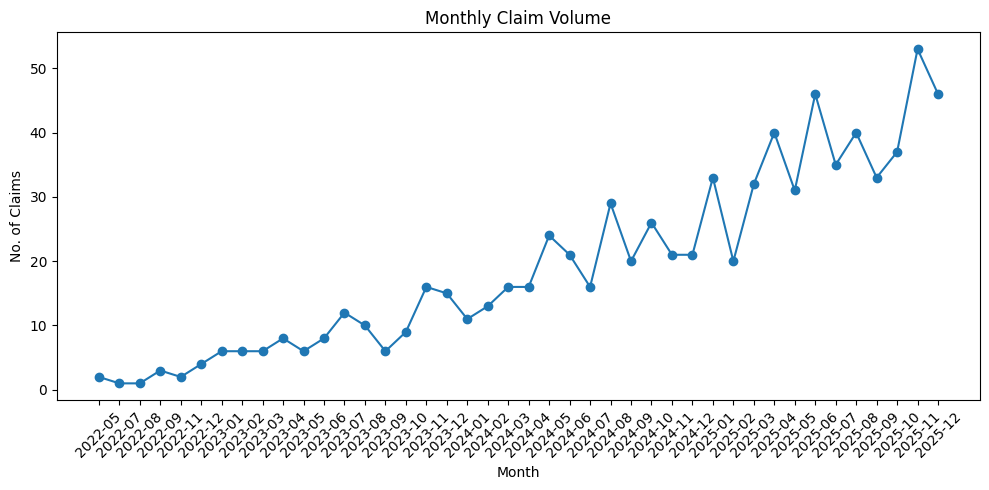

In [28]:
plt.figure(figsize=(10, 5))
plt.plot(kpi6["month"], kpi6["no_of_claims"], marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Claim Volume")
plt.xlabel("Month")
plt.ylabel("No. of Claims")
plt.tight_layout()
plt.show()

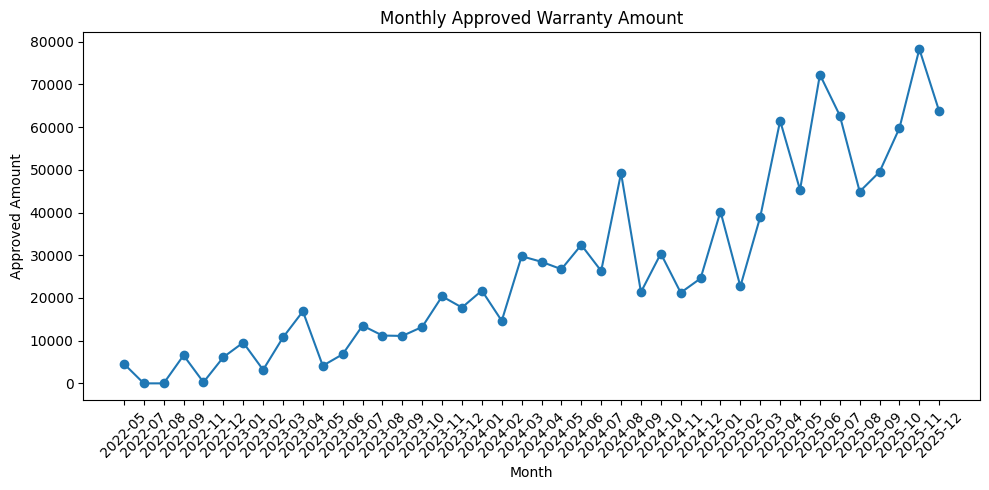

In [29]:
plt.figure(figsize=(10, 5))
plt.plot(kpi6["month"], kpi6["total_approved_amount"], marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Approved Warranty Amount")
plt.xlabel("Month")
plt.ylabel("Approved Amount")
plt.tight_layout()
plt.show()

These charts show how warranty activity evolves over time.

### issue category analysis

In [30]:
kpi3 = pd.read_sql_query("""
select issue_category, 
count(claim_id) as no_of_claims,
round(avg(claim_cost),2) as avg_claim_cost,
round(sum(claim_cost),2) as total_claim_cost
from valid_warranty_claims
group by issue_category
order by no_of_claims desc;
""", conn)

kpi3

,issue_category,no_of_claims,avg_claim_cost,total_claim_cost
0,HVAC,147,2502.81,367913.75
1,Powertrain,140,2498.40,349776.55
2,Infotainment,136,2640.91,359164.14
3,Body & Exterior,133,2725.79,362530.48
4,Electrical,123,2610.43,321082.92
5,Brakes,122,2666.15,325270.61


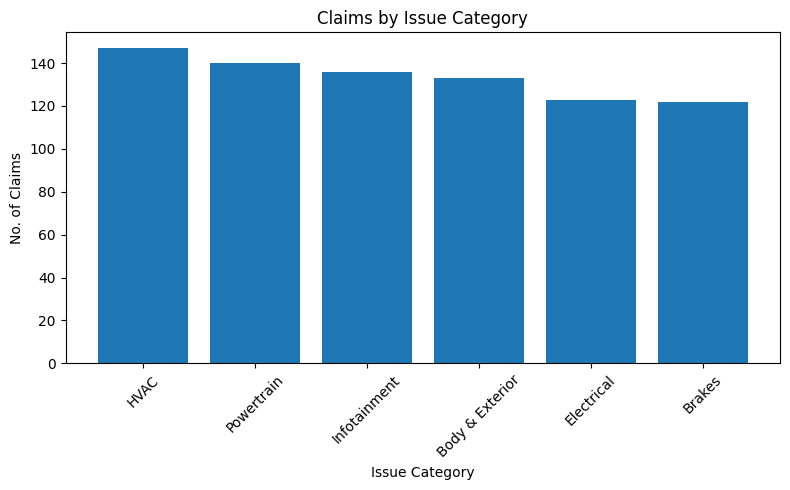

In [31]:
plt.figure(figsize=(8, 5))
plt.bar(kpi3["issue_category"], kpi3["no_of_claims"])
plt.xticks(rotation=45)
plt.title("Claims by Issue Category")
plt.xlabel("Issue Category")
plt.ylabel("No. of Claims")
plt.tight_layout()
plt.show()

This bar graph displays the most frequent issue categories and highlights the main drivers of warranty demand.

### rejection rate by issue category

In [32]:
kpi5 = pd.read_sql_query("""
select issue_category, 
count(claim_id) as total_claims,
sum(case when claim_status = 'Rejected' then 1 else 0 end) as rejected_claims,
round(100.0 * sum(case when claim_status = 'Rejected' then 1 else 0 end) / count(claim_id), 2) as rejection_rate
from valid_warranty_claims
group by issue_category
order by rejection_rate desc;
""", conn)

kpi5

,issue_category,total_claims,rejected_claims,rejection_rate
0,Powertrain,140,42,30.00
1,HVAC,147,36,24.49
2,Body & Exterior,133,32,24.06
3,Brakes,122,24,19.67
4,Infotainment,136,25,18.38
5,Electrical,123,15,12.20


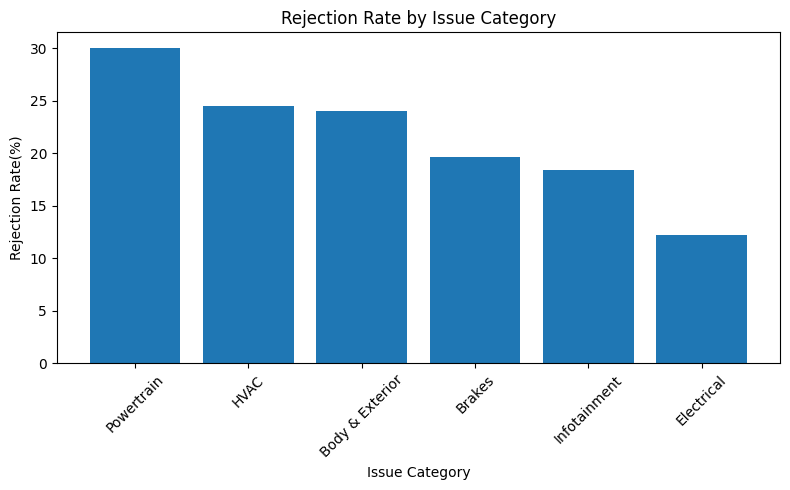

In [33]:
plt.figure(figsize=(8, 5))
plt.bar(kpi5["issue_category"], kpi5["rejection_rate"])
plt.xticks(rotation=45)
plt.title("Rejection Rate by Issue Category")
plt.xlabel("Issue Category")
plt.ylabel("Rejection Rate(%)")
plt.tight_layout()
plt.show()

### resolution time analysis

In [34]:
kpi8 = pd.read_sql_query("""
select issue_category,
round(avg(resolution_days),1) as avg_resolution_days
from valid_warranty_claims
group by issue_category
order by avg_resolution_days desc;
""",conn)

kpi8

,issue_category,avg_resolution_days
0,Brakes,32.9
1,HVAC,32.3
2,Infotainment,30.8
3,Powertrain,30.2
4,Body & Exterior,29.2
5,Electrical,27.8


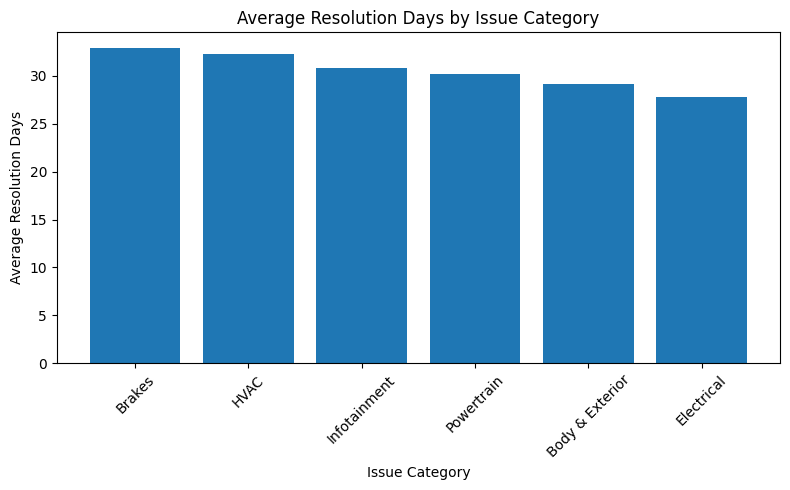

In [35]:
plt.figure(figsize=(8, 5))
plt.bar(kpi8["issue_category"], kpi8["avg_resolution_days"])
plt.xticks(rotation=45)
plt.title("Average Resolution Days by Issue Category")
plt.xlabel("Issue Category")
plt.ylabel("Average Resolution Days")
plt.tight_layout()
plt.show()

Longer average resolution times displayed in the bar graph may indicate more complex issues.

### model analysis

In [36]:
kpi2 = pd.read_sql_query("""
select vehicles.model,
count(valid_warranty_claims.claim_id) as no_of_claims,
count(distinct vehicles.vehicle_id) AS no_of_vehicles,
round(100.0 * count(valid_warranty_claims.claim_id) / count(distinct vehicles.vehicle_id), 2) AS claims_per_100_vehicles,
round(avg(valid_warranty_claims.claim_cost),2) as avg_claim_cost,
round(coalesce(sum(valid_warranty_claims.claim_cost), 0), 2) as total_claim_cost,
round(coalesce(sum(valid_warranty_claims.approved_amount), 0), 2) as total_approved_cost
from vehicles
left join valid_warranty_claims on valid_warranty_claims.vehicle_id = vehicles.vehicle_id
group by vehicles.model
order by claims_per_100_vehicles desc;
""", conn)

kpi2

,model,no_of_claims,no_of_vehicles,claims_per_100_vehicles,avg_claim_cost,total_claim_cost,total_approved_cost
0,Sorento,126,136,92.65,2449.05,308580.16,188599.41
1,Stinger,125,151,82.78,2539.48,317434.67,157800.14
2,Sportage,119,147,80.95,2647.96,315107.66,164290.57
3,Niro,112,141,79.43,2507.80,280873.29,130939.32
4,Ceed,122,155,78.71,2700.76,329492.50,174002.35
5,EV9,108,138,78.26,2882.29,311287.35,183023.70
6,EV6,89,132,67.42,2505.20,222962.82,124070.23


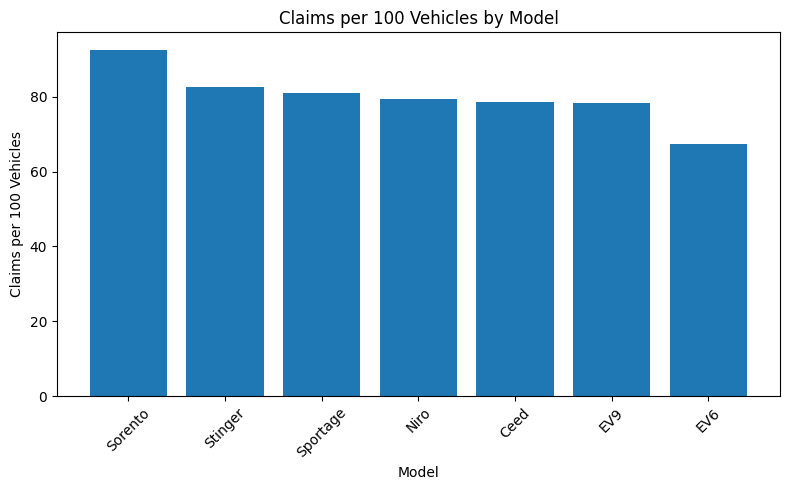

In [37]:
plt.figure(figsize=(8, 5))
plt.bar(kpi2["model"], kpi2["claims_per_100_vehicles"])
plt.xticks(rotation=45)
plt.title("Claims per 100 Vehicles by Model")
plt.xlabel("Model")
plt.ylabel("Claims per 100 Vehicles")
plt.tight_layout()
plt.show()

### warranty cost per vehicle by model

In [38]:
kpi13 = pd.read_sql_query("""
SELECT v.model,
       ROUND(SUM(COALESCE(w.approved_amount,0)) / COUNT(DISTINCT v.vehicle_id), 2) AS approved_cost
FROM vehicles v
LEFT JOIN valid_warranty_claims w ON v.vehicle_id = w.vehicle_id
GROUP BY v.model
ORDER BY approved_cost DESC;
""",conn)

kpi13

,model,approved_cost
0,Sorento,1386.76
1,EV9,1326.26
2,Ceed,1122.60
3,Sportage,1117.62
4,Stinger,1045.03
5,EV6,939.93
6,Niro,928.65


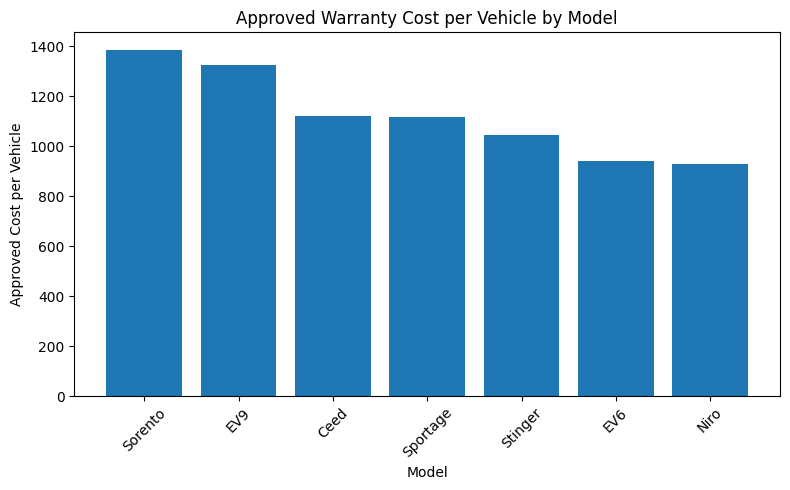

In [39]:
plt.figure(figsize=(8, 5))
plt.bar(kpi13["model"], kpi13["approved_cost"])
plt.xticks(rotation=45)
plt.title("Approved Warranty Cost per Vehicle by Model")
plt.xlabel("Model")
plt.ylabel("Approved Cost per Vehicle")
plt.tight_layout()
plt.show()

This bar graph displays the approved warranty cost for each model and helps compare which models are relatively more expensive from a warranty point of view.

### service analysis

In [40]:
kpi9 = pd.read_sql_query("""
select service_type,
count(service_id) as no_of_service_visits,
round(avg(service_cost),2) as avg_service_cost,
round(sum(service_cost),2) as total_service_cost
from valid_service_visits
group by service_type
order by no_of_service_visits desc;
""", conn)

kpi9

,service_type,no_of_service_visits,avg_service_cost,total_service_cost
0,Repair,595,791.86,471154.81
1,Emergency Repair,587,764.67,448861.24
2,Inspection,586,780.52,457386.50
3,Routine Maintenance,566,792.05,448302.92


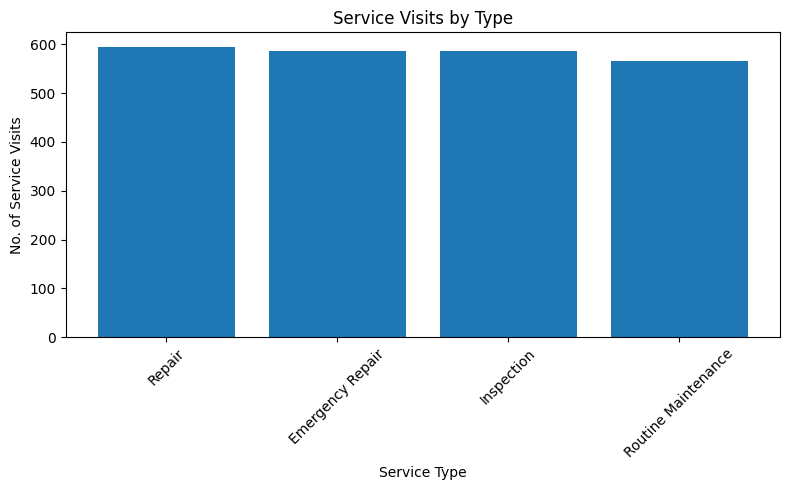

In [41]:
plt.figure(figsize=(8, 5))
plt.bar(kpi9["service_type"], kpi9["no_of_service_visits"])
plt.xticks(rotation=45)
plt.title("Service Visits by Type")
plt.xlabel("Service Type")
plt.ylabel("No. of Service Visits")
plt.tight_layout()
plt.show()

In [42]:
kpi10 = pd.read_sql_query("""
select vehicles.model as model,
round(avg(valid_service_visits.service_cost),2) as avg_service_cost
from valid_service_visits
join vehicles on valid_service_visits.vehicle_id=vehicles.vehicle_id
group by model
order by avg_service_cost desc;
""", conn)

kpi10

,model,avg_service_cost
0,Stinger,812.96
1,Sorento,799.68
2,Ceed,791.95
3,EV6,781.00
4,Niro,773.79
5,Sportage,765.48
6,EV9,749.86


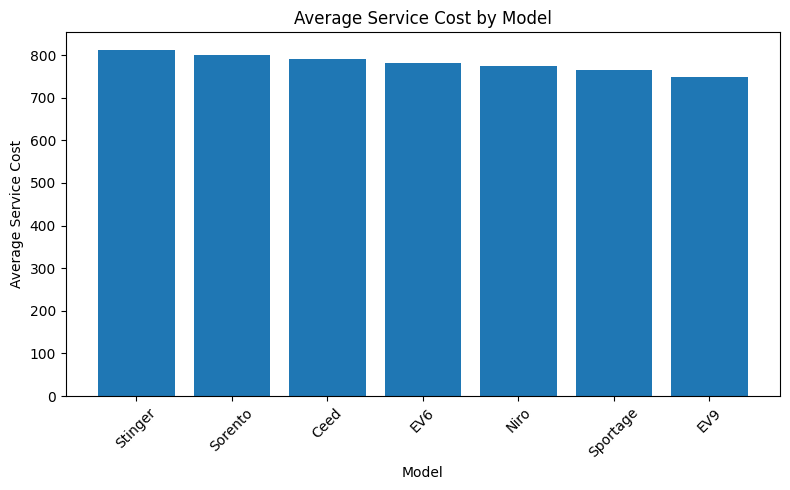

In [43]:
plt.figure(figsize=(8, 5))
plt.bar(kpi10["model"], kpi10["avg_service_cost"])
plt.xticks(rotation=45)
plt.title("Average Service Cost by Model")
plt.xlabel("Model")
plt.ylabel("Average Service Cost")
plt.tight_layout()
plt.show()

### regional analysis

In [46]:
kpi7 = pd.read_sql_query("""
select vehicles.city as city,
vehicles.region as region,
count(claim_id) as no_of_claims,
round(avg(valid_warranty_claims.claim_cost),2) as avg_claim_cost,
round(sum(valid_warranty_claims.claim_cost),2) as total_claim_cost
from valid_warranty_claims
join vehicles on vehicles.vehicle_id=valid_warranty_claims.vehicle_id
group by city,region
order by no_of_claims desc;
""", conn)

region_df = (
    kpi7.groupby("region", as_index=False)["no_of_claims"]
    .sum()
    .sort_values("no_of_claims", ascending=False)
)

region_df

,region,no_of_claims
3,South,276
4,West,156
1,East,150
2,North,127
0,Central,92


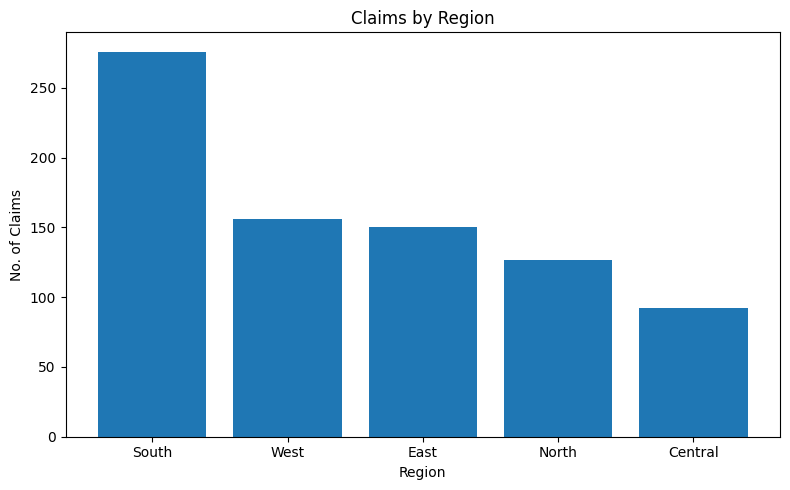

In [47]:
plt.figure(figsize=(8, 5))
plt.bar(region_df["region"], region_df["no_of_claims"])
plt.title("Claims by Region")
plt.xlabel("Region")
plt.ylabel("No. of Claims")
plt.tight_layout()
plt.show()

### Key Findings and Observations

- Some raw records fell outside the warranty period, so cleaned SQL views were created to ensure that only valid in-warranty activity was analyzed.

- Warranty burden is not evenly distributed across issue categories; a limited number of categories account for a relatively large share of claims and cost.

- Claim approval and rejection patterns vary by issue category, suggesting differences in policy fit, documentation, or issue severity.

- Resolution time also differs across issue categories, indicating potential operational bottlenecks.

- Model comparisons are more informative when normalized. Metrics such as claims per 100 vehicles and approved warranty cost per vehicle provide a more realistic view than raw claim counts alone.

- Service activity varies across service types and models, highlighting the value of combining service and warranty analysis rather than treating them separately.

- Regional differences in claim concentration may point to differences in vehicle mix, usage patterns, or service processes.